In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [4]:
X, y = make_moons(100, noise=0.25,random_state=2)

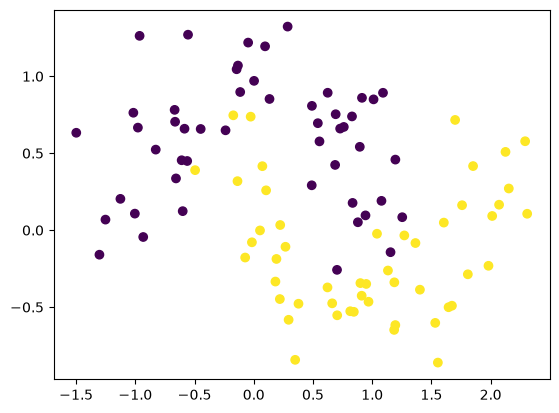

In [5]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [ ]:
model = Sequential()

model.add(Dense(2,activation='tanh',input_dim=2)) #try with tanh, relu
model.add(Dense(1,activation='sigmoid'))

model.summary()

c:\Users\sujat\projects\DeepLearning\100-Days-of-Deep-Learning\myvenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Set parameters to 0
model.get_weights()

[array([[ 0.32062948,  0.8426181 ],
        [-1.0518786 ,  0.5090231 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[ 0.8759049 ],
        [-0.10590935]], dtype=float32),
 array([0.], dtype=float32)]

In [31]:
initial_weights = model.get_weights()

In [ ]:
# initial_weights[0] = np.ones(model.get_weights()[0].shape)*0.5
# initial_weights[1] = np.ones(model.get_weights()[1].shape)*0.5
# initial_weights[2] = np.ones(model.get_weights()[2].shape)*0.5
# initial_weights[3] = np.ones(model.get_weights()[3].shape)*0.5

In [34]:
initial_weights[0] = np.zeros(model.get_weights()[0].shape)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.zeros(model.get_weights()[2].shape)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)

In [35]:
initial_weights

[array([[0., 0.],
        [0., 0.]]),
 array([0., 0.]),
 array([[0.],
        [0.]]),
 array([0.])]

In [36]:
model.set_weights(initial_weights)

In [37]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.], dtype=float32)]

In [38]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [39]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 277ms/step - accuracy: 0.4625 - loss: 0.6931 - val_accuracy: 0.3500 - val_loss: 0.6935
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5375 - loss: 0.6930 - val_accuracy: 0.3500 - val_loss: 0.6937
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5375 - loss: 0.6931 - val_accuracy: 0.3500 - val_loss: 0.6939
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5375 - loss: 0.6929 - val_accuracy: 0.3500 - val_loss: 0.6940
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5375 - loss: 0.6929 - val_accuracy: 0.3500 - val_loss: 0.6941
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5375 - loss: 0.6929 - val_accuracy: 0.3500 - val_loss: 0.6943
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5375 - loss: 0.6929 - val_accuracy: 0.3500 - val_loss: 0.6945
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5375 - loss: 0.6928 - val_accuracy: 0.3500 - val_loss

In [41]:
model.get_weights()

[array([[0., 0.],
        [0., 0.]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[0.],
        [0.]], dtype=float32),
 array([0.08157088], dtype=float32)]

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

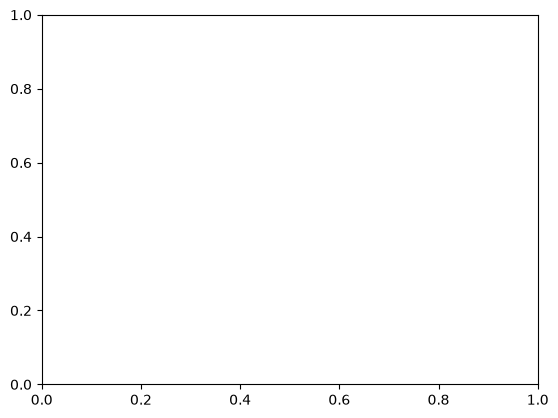

In [16]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step


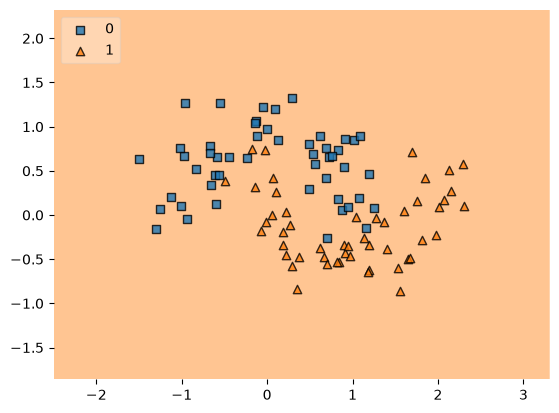

In [17]:
import numpy as np
from mlxtend.plotting import plot_decision_regions

# 1. Define a wrapper class to convert probabilities to binary classes (0 or 1)
class KerasClassifierWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        # Apply threshold 0.5 to convert probabilities to 0 or 1
        return (self.model.predict(X) > 0.5).astype(int).ravel()

# 2. Pass the wrapped model to plot_decision_regions
plot_decision_regions(X, y.astype('int'), clf=KerasClassifierWrapper(model), legend=2)
plt.show()
